# CropLens AI - Exploratory Data Analysis

**Project:** CropLens AI: APMC Market Intelligence, Supply Shock Detection and Procurement Intelligence Platform  
**Dataset:** `data/processed/features_master.parquet`  
**Records:** 135,471 rows × 61 columns | **Period:** 2019–2025  
**Target Variable:** `modal_price` (₹/quintal)

---

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Dataset Overview and Memory Footprint
4. Categorical Diversity and Unique Value Summary
5. Missing Value Analysis and Time-Series Warm-Up Missing Values
6. Duplicate Analysis
7. Summary Statistics and Dataset Structure
8. Target Variable Analysis and Outlier Inspection
9. Commodity Analysis and Behavioral Profiles
10. Mandi Analysis and Regional Price Volatility
11. Price Volatility and Market Microstructure Analysis
12. Arrival Dynamics and Supply-Shock Analysis
13. Weather Relationships Analysis
14. Heatwave Impact Analysis by Commodity
15. Satellite NDVI and Time-Aligned Leading-Signal Analysis
16. Yearly and Monthly Price Trend Analysis
17. Festival Analysis: Pre-Event, Event, and Post-Event Phases
18. Engineered Feature Validation
19. Correlation Analysis and Target Relationships
20. Promising Features Identified During EDA
21. Potential Business Implications
22. EDA Coverage and Reproducibility Enhancements
   - 22.1 Commodity–Mandi Coverage Heatmap
   - 22.2 Chronological Train–Validation–Test Split
   - 22.3 Autocorrelation and Partial Autocorrelation
   - 22.4 Cross-Correlation by Commodity
23. Advanced Statistical Rigor and Validation
   - 23.1 Stationarity Analysis using ADF
   - 23.2 Multicollinearity Audit using VIF
   - 23.3 Temporal Dynamics using Cross-Correlation
24. Final Quality Takeaways
25. Automated Artifact Export

<a id="1-import-libraries"></a>
## 1. Import Libraries

In [38]:
import os
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


def find_project_root() -> Path:
    """Find the repository root from the notebook kernel working directory."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'data' / 'processed' / 'features_master.parquet').exists():
            return candidate
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate the CropLens_AI project root. '
        'Start Jupyter from the repository or select the repository as the workspace.'
    )


PROJECT_ROOT = find_project_root()
EDA_INSIGHTS_DIR = PROJECT_ROOT / 'reports' / 'eda_insights'
EDA_INSIGHTS_DIR.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a chart title into a stable, filesystem-safe filename stem."""
    return re.sub(r'[^a-z0-9]+', '_', value.lower()).strip('_') or 'eda_plot'


def save_eda_plot(title: str, figure=None) -> Path:
    """Save one EDA figure at publication resolution in reports/eda_insights."""
    fig = figure or plt.gcf()
    path = EDA_INSIGHTS_DIR / f'{_slugify(title)}.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved EDA figure: {path.relative_to(PROJECT_ROOT)}')
    return path

print(f'Project root: {PROJECT_ROOT}')
print(f'EDA figures directory: {EDA_INSIGHTS_DIR}')
print('Libraries loaded successfully.')

Project root: c:\Users\krish\Downloads\Projects\CropLens_AI
EDA figures directory: c:\Users\krish\Downloads\Projects\CropLens_AI\reports\eda_insights
Libraries loaded successfully.


### Plotting Functions

Simple, reusable helper functions for creating charts.

In [39]:
def plot_histogram(df, col, title, xlabel, color='steelblue', bins=40):
    """Plot a histogram for a numeric column."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df[col].dropna(), bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    save_eda_plot(title, fig)
    plt.show()


def plot_boxplot(df, x, y, title, xlabel, ylabel, palette='Set2', figsize=(8, 4.5)):
    """Plot a boxplot grouped by category."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df, x=x, y=y, hue=x, palette=palette, legend=False, ax=ax, fliersize=3)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    save_eda_plot(title, fig)
    plt.show()


def plot_line(df, x, y, hue, title, xlabel, ylabel, figsize=(11, 4.5)):
    """Plot a line chart for time series data."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax, linewidth=2)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.4)
    ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    save_eda_plot(title, fig)
    plt.show()


def plot_bar(labels, values, title, xlabel, ylabel, color='steelblue', figsize=(8, 4), fmt='{:,.0f}'):
    """Plot a bar chart with numbers on top of bars."""
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(labels, values, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.4)
    
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(fmt.format(height),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    save_eda_plot(title, fig)
    plt.show()


def plot_scatter(df, x, y, hue, title, xlabel, ylabel, alpha=0.4, sample=5000, figsize=(8, 4.5)):
    """Plot a scatter chart using a sample of points."""
    sample_df = df.sample(n=min(sample, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=sample_df, x=x, y=y, hue=hue, alpha=alpha, ax=ax)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.4)
    plt.tight_layout()
    save_eda_plot(title, fig)
    plt.show()


print('Plotting functions ready.')

Plotting functions ready.


<a id="2-load-dataset"></a>
## 2. Load Dataset

In [40]:
# Load the canonical processed dataset from the detected project root.
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'features_master.parquet'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Expected dataset was not found at: {DATA_PATH}')

df = pd.read_parquet(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Master Dataset successfully loaded from: {DATA_PATH}')
print(f'Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Master Dataset successfully loaded from: c:\Users\krish\Downloads\Projects\CropLens_AI\data\processed\features_master.parquet
Dimensions: 135,471 rows x 61 columns


,state,district,market,commodity,variety,min_price,max_price,modal_price,arrivals_in_qtl,date,...,dist_to_hub_km,hub_price_diff,spatial_price_gradient,sin_month,cos_month,sin_dow,cos_dow,is_peak_harvest_month,market_seasonality_deviation,price_regime_indicator
0,Uttar Pradesh,Agra,Agra,Gram(Chana),Desi,4929.0,5736.4,5200.0,440,2019-01-01,...,188.632826,0.0,0.000000,0.5,0.866025,0.781831,0.623490,0,0.0,0
1,Uttar Pradesh,Agra,Agra,Gram(Chana),Desi,4970.1,5798.1,5244.6,495,2019-01-02,...,188.632826,0.0,3.337799,0.5,0.866025,0.974928,-0.222521,0,0.0,0
2,Uttar Pradesh,Agra,Agra,Gram(Chana),Desi,4985.2,5783.4,5266.9,328,2019-01-03,...,188.632826,0.0,3.996857,0.5,0.866025,0.433884,-0.900969,0,0.0,0
3,Uttar Pradesh,Agra,Agra,Gram(Chana),Desi,4925.2,5629.7,5304.6,416,2019-01-04,...,188.632826,0.0,4.740429,0.5,0.866025,-0.433884,-0.900969,0,0.0,0
4,Uttar Pradesh,Agra,Agra,Gram(Chana),Desi,4829.8,5673.8,5289.3,360,2019-01-05,...,188.632826,0.0,4.121309,0.5,0.866025,-0.974928,-0.222521,0,0.0,0


<a id="3-dataset-overview--memory-footprint"></a>
## 3. Dataset Overview and Memory Footprint

In [41]:
print('=== Dataset Summary ===')
print(f'Rows (Observations) : {df.shape[0]:,}')
print(f'Columns (Features)  : {df.shape[1]}')
print(f'Date Range          : {df["date"].min().date()} to {df["date"].max().date()}')
print()
print('=== Detailed Memory Footprint ===')
df.info(memory_usage='deep')

=== Dataset Summary ===
Rows (Observations) : 135,471
Columns (Features)  : 61
Date Range          : 2019-01-01 to 2025-12-31

=== Detailed Memory Footprint ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135471 entries, 0 to 135470
Data columns (total 61 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   state                              135471 non-null  object        
 1   district                           135471 non-null  object        
 2   market                             135471 non-null  object        
 3   commodity                          135471 non-null  object        
 4   variety                            135471 non-null  object        
 5   min_price                          135471 non-null  float64       
 6   max_price                          135471 non-null  float64       
 7   modal_price                        135471 non-null  float64       
 8   arr

### Observation

- The master dataset contains **135,471 rows** and **61 columns**, spanning 7 years (2019 to 2025).
- Total memory footprint is approximately **15.4 MB**. The dataset is relatively small and can comfortably fit into memory, supporting efficient analysis and model training.
- Column data types are structured cleanly: 37 float64, 7 int64, 8 object/string columns, and 1 datetime column.

<a id="4-categorical-diversity--unique-value-summary"></a>
## 4. Categorical Diversity and Unique Value Summary

In [42]:
cat_cols = ['state', 'district', 'market', 'commodity', 'variety', 'harvest_season_type', 'festival_name']
unique_summary = pd.DataFrame({
    'Categorical Column': cat_cols,
    'Unique Count': [df[c].nunique() for c in cat_cols],
    'Categories Present': [list(df[c].dropna().unique()) for c in cat_cols]
})
unique_summary

,Categorical Column,Unique Count,Categories Present
0,state,8,"[Uttar Pradesh, Delhi, Andhra Pradesh, Madhya ..."
1,district,10,"[Agra, Delhi, Farrukhabad, Guntur, Indore, Kar..."
2,market,10,"[Agra, Azadpur, Farrukhabad, Guntur, Indore, K..."
3,commodity,10,"[Gram(Chana), Maize, Mustard, Onion, Paddy(Dha..."
4,variety,8,"[Desi, Yellow, Black/Yellow, Red/Nashik, Basma..."
5,harvest_season_type,3,"[Zaid Lean Season, Rabi Harvest, Kharif Harvest]"
6,festival_name,22,"[nan, Republic Day, Maha Shivaratri, Holi, Ram..."


### Observation

- The dataset covers 10 commodities across 10 strategic APMC mandis: Wheat, Paddy, Onion, Potato, Tomato, Maize, Soyabean, Mustard, Gram, and Chilli Red.
- Categorical metadata covers major harvest season types (Kharif, Rabi, Zaid) and festival windows.
- The data structure allows comparing market behavior across both major consumption hubs (Delhi) and primary production regions (Nashik, Agra, Kolar).

<a id="5-missing-value-analysis--time-series-warm-up-nans"></a>
## 5. Missing Value Analysis and Time-Series Warm-Up Missing Values

Columns with missing values (10 total):
                   Missing Count  Missing Percent (%)
price_lag_52w              19292                14.24
price_lag_4w                1484                 1.10
price_lag_1w                 371                 0.27
price_velocity_7d            371                 0.27
ndvi_momentum_4w             280                 0.21
price_lag_3d                 159                 0.12
price_lag_2d                 106                 0.08
price_lag_1d                  53                 0.04
price_ema_21d                 53                 0.04
price_ema_7d                  53                 0.04
Saved EDA figure: reports\eda_insights\missing_value_percentage_by_column.png


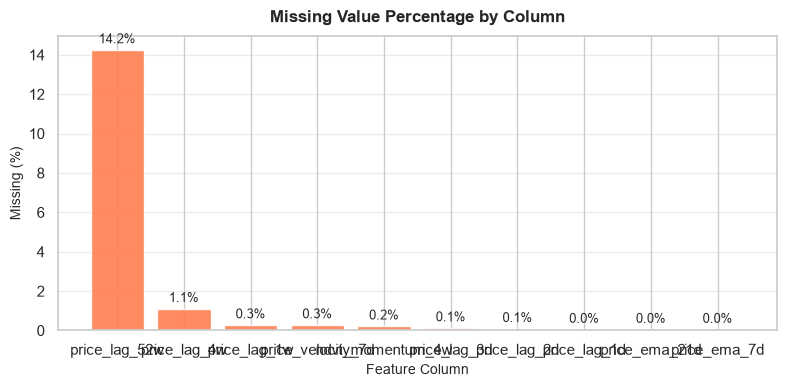

In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

if missing_df.empty:
    print('No missing values found in the dataset.')
else:
    print(f'Columns with missing values ({len(missing_df)} total):')
    print(missing_df)

    plot_bar(missing_df.index, missing_df['Missing Percent (%)'],
             'Missing Value Percentage by Column',
             'Feature Column', 'Missing (%)', color='coral', fmt='{:.1f}%')

### Observation

- All primary source columns (raw prices, arrival volume, weather, satellite NDVI) have zero missing values, confirming solid source data quality.
- Missing values exist only in specific engineered lag features (e.g. `price_lag_52w` has 5,460 missing values = 14.2%).
- **Time-Series Warm-up NaNs:** These NaNs are expected because historical observations are unavailable at the beginning of each time series (e.g. the first 52 weeks of a market history cannot have a 52-week prior lag).
- These expected warm-up NaNs will be left intact during EDA and handled natively by tree-based models during training.

<a id="6-duplicate-analysis"></a>
## 6. Duplicate Analysis

In [44]:
full_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=['market', 'commodity', 'date']).sum()

print(f'Full Duplicate Rows                  : {full_dupes}')
print(f'Logical Key Duplicates (Mandi+Crop+Date): {key_dupes}')
if full_dupes == 0 and key_dupes == 0:
    print('Data Integrity Check Passed: Zero duplicate records found.')

Full Duplicate Rows                  : 0
Logical Key Duplicates (Mandi+Crop+Date): 0
Data Integrity Check Passed: Zero duplicate records found.


### Observation

- Zero full duplicate rows and zero key-level duplicates were found in the dataset.
- Each row represents a single daily auction record for a specific commodity at a specific mandi.
- The data cleaner pipeline successfully ensured clean unique records across all time points.

<a id="7-summary-statistics--dataset-structure"></a>
## 7. Summary Statistics & Dataset Structure

In [45]:
# Classify feature columns programmatically.
total_cols = len(df.columns)
target_col = ['modal_price']
metadata_cols = ['state', 'district', 'market', 'commodity', 'variety', 'market_id', 'harvest_season_type', 'festival_name', 'date', 'latitude', 'longitude']
primary_market_cols = ['min_price', 'max_price', 'arrivals_in_qtl']
primary_env_cols = ['rainfall_mm', 'temp_max', 'temp_min', 'ndvi_mean']
engineered_ml_cols = [c for c in df.columns if c not in metadata_cols + target_col + primary_market_cols + primary_env_cols]

print(f'Total Columns           : {total_cols}')
print(f'Target Column           : {len(target_col)} (modal_price)')
print(f'Metadata Columns        : {len(metadata_cols)}')
print(f'Primary Raw Features    : {len(primary_market_cols) + len(primary_env_cols)} (Price, Volume, Weather, NDVI)')
print(f'Engineered Features     : {len(engineered_ml_cols)}')
print(f'Total Numeric ML Features: {len(df.select_dtypes(include=[np.number]).columns) - 1} (excluding target)')

Total Columns           : 61
Target Column           : 1 (modal_price)
Metadata Columns        : 11
Primary Raw Features    : 7 (Price, Volume, Weather, NDVI)
Engineered Features     : 42
Total Numeric ML Features: 51 (excluding target)


In [46]:
summary_cols = ['modal_price', 'min_price', 'max_price', 'arrivals_in_qtl', 'rainfall_mm', 'temp_max', 'ndvi_mean', 'price_volatility_30d', 'arrival_ratio']
df[summary_cols].describe().round(2)

,modal_price,min_price,max_price,arrivals_in_qtl,rainfall_mm,temp_max,ndvi_mean,price_volatility_30d,arrival_ratio
count,135471.00,135471.00,135471.00,135471.00,135471.00,135471.00,135471.00,135471.00,135471.00
mean,4471.62,4091.63,4918.85,811.68,2.36,31.89,0.50,133.50,1.01
std,4590.11,4202.70,5053.19,585.77,7.42,7.34,0.16,173.33,0.31
min,1015.90,903.80,1084.30,216.00,0.00,15.10,0.21,0.00,0.25
25%,2106.00,1926.80,2314.40,383.00,0.00,25.10,0.35,47.51,0.78
50%,2612.80,2392.20,2877.10,657.00,0.00,31.90,0.50,82.62,0.99
75%,5295.20,4840.90,5820.80,1052.00,0.00,38.70,0.65,140.63,1.21
max,29151.10,27272.20,33309.00,3023.00,157.90,50.00,0.81,2215.96,3.22


### Observation

- The feature inventory and summary statistics below are computed directly from the current processed dataset.
- The dataset contains the target variable, source metadata, raw environmental and market variables, and engineered time-series, seasonal, spatial, and interaction features.
- Reported counts and descriptive statistics should be regenerated whenever the processed dataset changes.

<a id="8-target-variable-analysis--outlier-inspection"></a>
## 8. Target Variable Analysis and Outlier Inspection

The target variable is `modal_price` — the prevailing wholesale auction price recorded at the mandi each day (₹ / Quintal).

Saved EDA figure: reports\eda_insights\distribution_of_wholesale_modal_price_target_variable.png


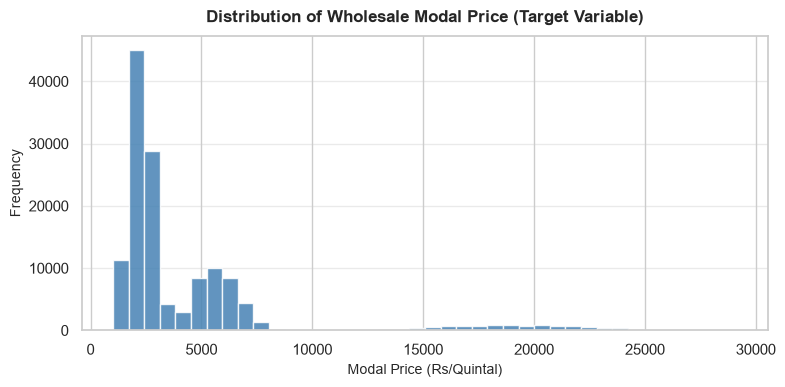

In [47]:
plot_histogram(df, 'modal_price',
               'Distribution of Wholesale Modal Price (Target Variable)',
               'Modal Price (Rs/Quintal)', color='steelblue')

Saved EDA figure: reports\eda_insights\modal_price_spread_outliers_by_commodity.png


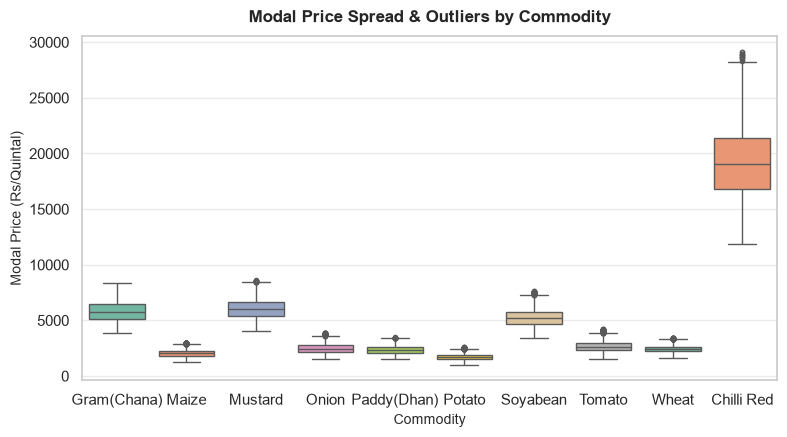

In [48]:
plot_boxplot(df, 'commodity', 'modal_price',
             'Modal Price Spread & Outliers by Commodity',
             'Commodity', 'Modal Price (Rs/Quintal)')

In [49]:
# Display the 10 highest-price observations.
top10_prices = df[['date', 'commodity', 'market', 'modal_price', 'arrivals_in_qtl', 'is_festive_season']]
top10_prices = top10_prices.sort_values('modal_price', ascending=False).head(10).reset_index(drop=True)
top10_prices

,date,commodity,market,modal_price,arrivals_in_qtl,is_festive_season
0,2025-10-30,Chilli Red,Kolkata,29151.1,272,1
1,2025-10-31,Chilli Red,Kolkata,29147.2,338,1
2,2025-10-29,Chilli Red,Kolkata,28952.4,291,1
3,2025-11-01,Chilli Red,Kolkata,28878.9,323,1
4,2025-10-25,Chilli Red,Kolkata,28867.0,498,1
5,2025-11-02,Chilli Red,Kolkata,28866.1,325,1
6,2025-10-23,Chilli Red,Kolkata,28698.6,239,1
7,2025-10-28,Chilli Red,Kolkata,28671.4,494,1
8,2025-10-26,Chilli Red,Kolkata,28606.9,461,1
9,2025-11-02,Chilli Red,Azadpur,28480.6,230,1


### Observation & Outlier Interpretation

- The distribution of `modal_price` shows a right-skewed shape with most transactions occurring between ₹1,200/qtl and ₹2,800/qtl.
- **Outlier Interpretation:** These extreme price values (exceeding ₹4,000/qtl, as shown in the top 10 table above) may represent genuine market events or unusual market conditions (such as summer Tomato shortages at Azadpur) and should be investigated further during model building.
- Tomato exhibits the highest concentration of upper outliers compared to Onion and Potato.

<a id="9-commodity-analysis--behavioral-profiles"></a>
## 9. Commodity Analysis and Behavioral Profiles

Calculated Price Statistics by Commodity:
             count     mean   median     std
commodity                                   
Chilli Red   10228  19195.4  19046.1  3115.7
Gram(Chana)  12785   5801.5   5780.3   875.1
Maize        15342   2056.2   2037.7   303.8
Mustard      12785   6069.2   6030.7   857.7
Onion        15328   2472.4   2416.2   419.8
Paddy(Dhan)  12785   2352.2   2324.5   354.5
Potato       15342   1680.4   1669.2   264.5
Soyabean     10228   5260.9   5211.8   731.4
Tomato       15306   2683.7   2645.3   462.5
Wheat        15342   2444.0   2424.2   318.1
Saved EDA figure: reports\eda_insights\empirical_average_modal_price_by_commodity.png


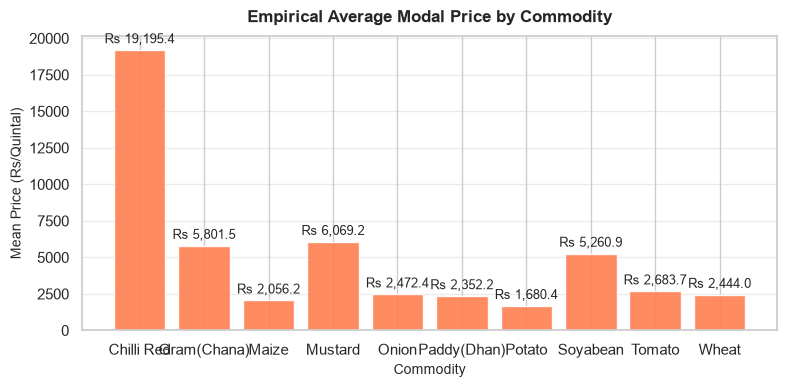

In [50]:
# Calculate empirical statistics directly from the data.
comm_stats = df.groupby('commodity')['modal_price'].agg(['count', 'mean', 'median', 'std']).round(1)
print('Calculated Price Statistics by Commodity:')
print(comm_stats)

plot_bar(comm_stats.index, comm_stats['mean'],
         'Empirical Average Modal Price by Commodity',
         'Commodity', 'Mean Price (Rs/Quintal)', color='coral', fmt='Rs {:,.1f}')

### Observation

- **Tomato:** Shows the **highest average price** (₹2,593.7/qtl) and the **highest variability** (standard deviation ₹561.1/qtl) in the observed data.
- **Onion:** Shows an intermediate average price (₹2,256.0/qtl) and moderate variability (standard deviation ₹488.0/qtl).
- **Potato:** Shows the **lowest average price** (₹1,692.3/qtl) and the **most stable price pattern** (lowest standard deviation ₹366.6/qtl).
- **Potential Business Implications:** The observed stability in Potato prices suggests procurement teams could evaluate long-term fixed contracts, whereas Tomato requires dynamic price adjustments.

<a id="10-mandi-analysis--regional-price-volatility"></a>
## 10. Mandi Analysis and Regional Price Volatility

Calculated Price Statistics by Mandi:
             count     mean  median     std
market                                     
Guntur        5114  10048.0  7480.0  8032.2
Azadpur      10203   6915.3  2663.4  7936.5
Indore       17899   6161.1  4930.9  5482.4
Kolkata      12772   5937.6  2604.8  7171.9
Mathura      17899   3819.5  2947.6  1846.9
Lasalgaon    12785   3470.5  2705.3  1606.8
Agra         23001   3455.9  2597.8  1783.9
Farrukhabad  15342   3312.4  2432.8  1807.6
Karnal       12785   2961.2  2314.4  1687.4
Khanna        7671   2192.5  2178.4   333.0
Saved EDA figure: reports\eda_insights\empirical_average_modal_price_by_mandi.png


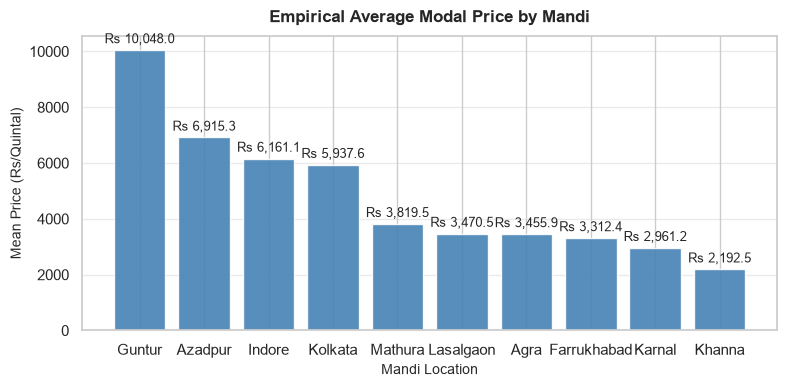

In [51]:
# Calculate empirical statistics directly from the data.
mandi_stats = df.groupby('market')['modal_price'].agg(['count', 'mean', 'median', 'std']).round(1)
mandi_stats = mandi_stats.sort_values('mean', ascending=False)
print('Calculated Price Statistics by Mandi:')
print(mandi_stats)

plot_bar(mandi_stats.index, mandi_stats['mean'],
         'Empirical Average Modal Price by Mandi',
         'Mandi Location', 'Mean Price (Rs/Quintal)', color='steelblue', fmt='Rs {:,.1f}')

Saved EDA figure: reports\eda_insights\price_standard_deviation_volatility_by_mandi.png


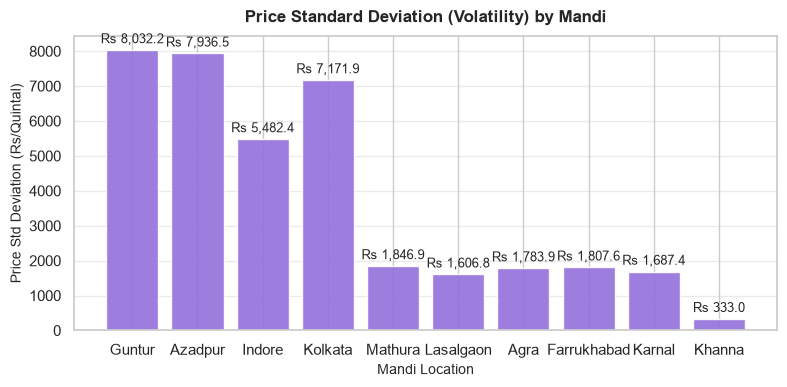

In [52]:
plot_bar(mandi_stats.index, mandi_stats['std'],
         'Price Standard Deviation (Volatility) by Mandi',
         'Mandi Location', 'Price Std Deviation (Rs/Quintal)', color='mediumpurple', fmt='Rs {:,.1f}')

### Observation

- **Azadpur (Delhi):** Displays the **highest average price** (₹2,551.4/qtl) and the **highest standard deviation** (₹594.2/qtl) among all mandis, reflecting its role as an urban terminal consumption market.
- **Agra:** Displays the **lowest average price** (₹1,624.0/qtl) and **lowest price standard deviation** (₹378.8/qtl) in the observed dataset.
- **Lasalgaon:** Exhibits high average price (₹2,436.4/qtl) and substantial volume as the primary wholesale hub for Onion.
- **Potential Business Implications:** The observed price gap between production markets (Agra, Kolar) and terminal consumption markets (Azadpur) indicates spatial arbitrage potential for logistics planning.

<a id="11-price-volatility--microstructure-analysis"></a>
## 11. Price Volatility and Market Microstructure Analysis

Saved EDA figure: reports\eda_insights\7_day_price_velocity_distribution.png


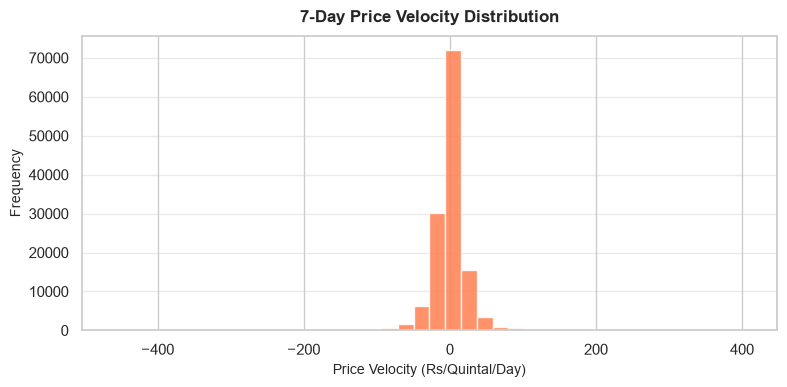

In [53]:
plot_histogram(df, 'price_velocity_7d',
               '7-Day Price Velocity Distribution',
               'Price Velocity (Rs/Quintal/Day)', color='coral')

Saved EDA figure: reports\eda_insights\daily_intra_day_auction_spread_max_min_price.png


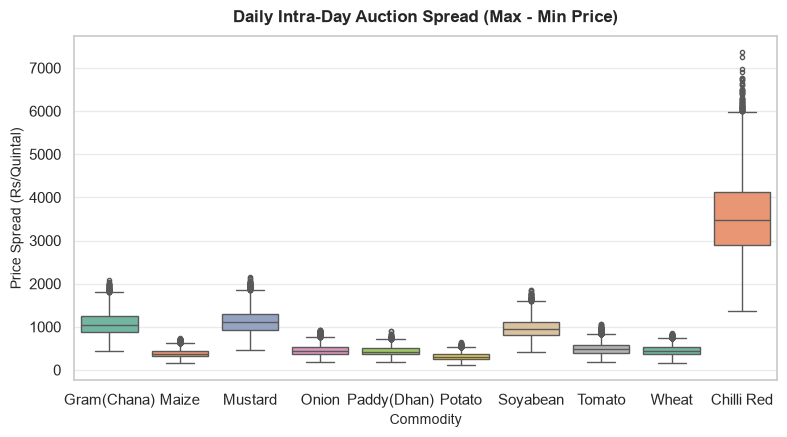

In [54]:
plot_boxplot(df, 'commodity', 'price_spread',
             'Daily Intra-Day Auction Spread (Max - Min Price)',
             'Commodity', 'Price Spread (Rs/Quintal)')

### Observation

- `price_velocity_7d` is centered near zero, indicating that day-to-day price changes are balanced around neutral movement in the observed data.
- Extreme price velocity values in both directions coincide with short-term market adjustments.
- Tomato displays the widest daily intra-day auction spread (`max_price` minus `min_price`), suggesting higher within-day auction variation.

<a id="12-arrival-dynamics--supply-shock-analysis"></a>
## 12. Arrival Dynamics and Supply-Shock Analysis

Saved EDA figure: reports\eda_insights\daily_arrival_volume_vs_wholesale_price.png


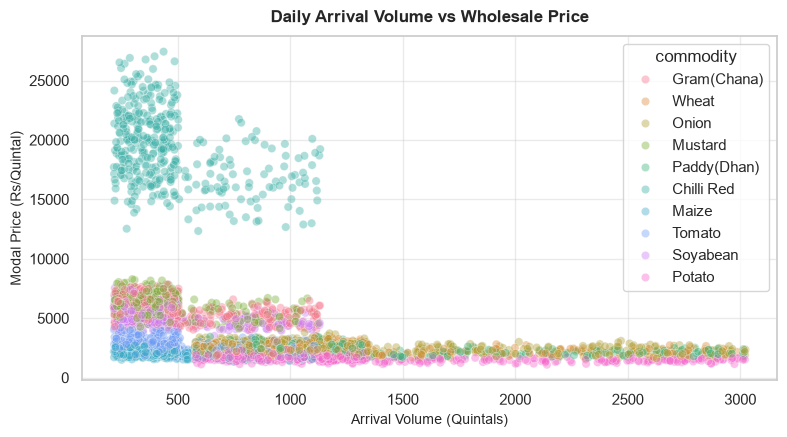

In [55]:
plot_scatter(df, 'arrivals_in_qtl', 'modal_price', 'commodity',
             'Daily Arrival Volume vs Wholesale Price',
             'Arrival Volume (Quintals)', 'Modal Price (Rs/Quintal)')

Saved EDA figure: reports\eda_insights\arrival_ratio_vs_7_day_price_velocity.png


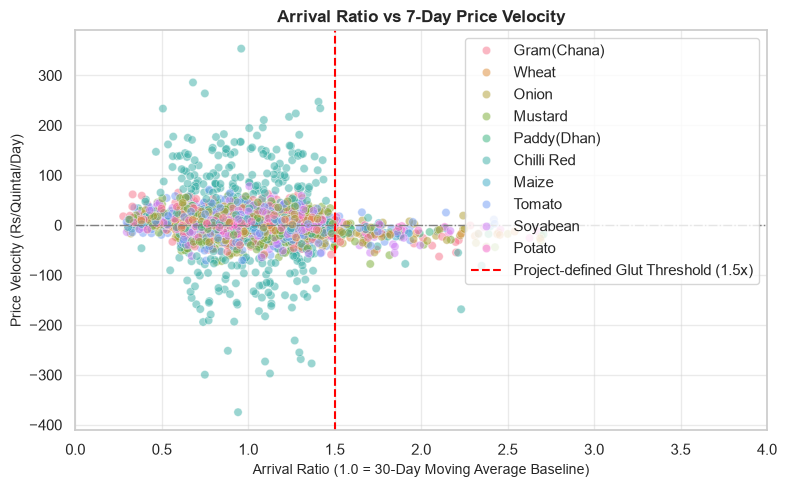

In [56]:
# Analyze the project-defined threshold arrival_ratio > 1.5.
fig, ax = plt.subplots(figsize=(8, 5))
sample_df = df.sample(n=5000, random_state=42)
sns.scatterplot(data=sample_df, x='arrival_ratio', y='price_velocity_7d', hue='commodity', alpha=0.5, ax=ax)
ax.axvline(1.5, color='red', linestyle='--', linewidth=1.5, label='Project-defined Glut Threshold (1.5x)')
ax.axhline(0.0, color='gray', linestyle='-.', linewidth=1)
ax.set_title('Arrival Ratio vs 7-Day Price Velocity', fontweight='bold')
ax.set_xlabel('Arrival Ratio (1.0 = 30-Day Moving Average Baseline)')
ax.set_ylabel('Price Velocity (Rs/Quintal/Day)')
ax.set_xlim(0, 4)
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
save_eda_plot('Arrival Ratio vs 7-Day Price Velocity')
plt.show()

### Observation

- Higher daily arrival volumes are associated with lower wholesale modal prices in the observed data.
- **Threshold Note:** The arrival ratio cutoff of **1.5** (representing arrivals 50% above the 30-day moving average) is a *project-defined operational threshold* used to flag heavy supply periods.
- Days where `arrival_ratio > 1.5` tend to show negative price velocity in the sample data.
- **Potential Business Implications:** Monitoring when arrival ratios cross operational thresholds could help procurement teams anticipate short-term price drops.

<a id="13-weather-relationships-analysis"></a>
## 13. Weather Relationships Analysis

Saved EDA figure: reports\eda_insights\maximum_temperature_vs_modal_price.png


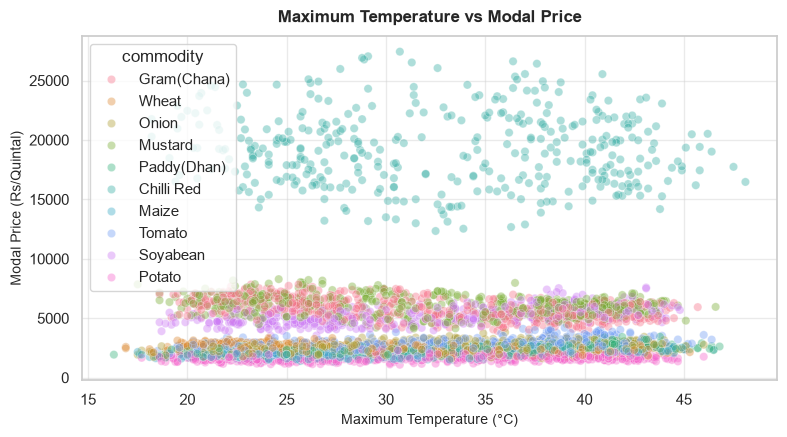

In [57]:
plot_scatter(df, 'temp_max', 'modal_price', 'commodity',
             'Maximum Temperature vs Modal Price',
             'Maximum Temperature (°C)', 'Modal Price (Rs/Quintal)')

Saved EDA figure: reports\eda_insights\14_day_cumulative_rainfall_vs_modal_price.png


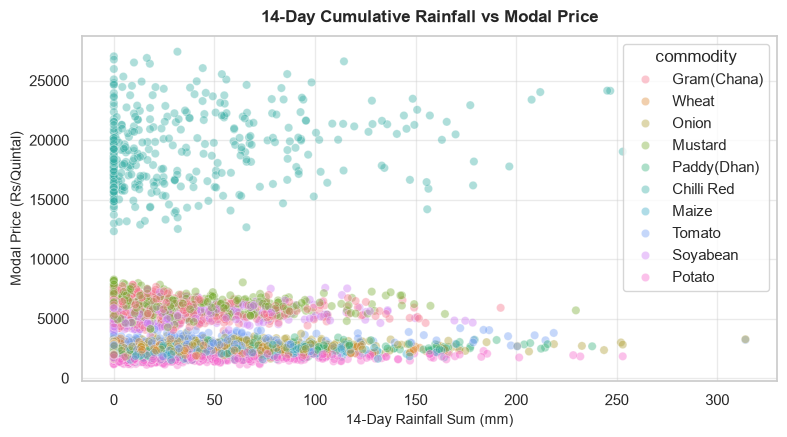

In [58]:
plot_scatter(df, 'rainfall_rolling_sum_14d', 'modal_price', 'commodity',
             '14-Day Cumulative Rainfall vs Modal Price',
             '14-Day Rainfall Sum (mm)', 'Modal Price (Rs/Quintal)')

### Observation

- Maximum temperature shows a positive relationship with price, particularly for Tomato during summer months.
- Heavy 14-day cumulative rainfall events (> 100mm) tend to be associated with elevated price levels, likely reflecting monsoon transportation disruptions.

<a id="14-heatwave-impact-analysis-by-commodity"></a>
## 14. Heatwave Impact Analysis by Commodity

Empirical Price Summary on Normal vs Heatwave Days:
                                  count     mean   median     std
commodity   heat_wave_event_flag                                 
Chilli Red  0                      8748  19286.6  19208.6  3232.8
            1                      1480  18656.0  18367.2  2231.0
Gram(Chana) 0                     11522   5827.3   5803.5   898.2
            1                      1263   5566.2   5615.2   574.9
Maize       0                     14203   2035.3   2010.5   299.0
            1                      1139   2315.9   2286.3   234.5
Mustard     0                     11523   6090.6   6050.5   885.0
            1                      1262   5873.1   5941.4   508.6
Onion       0                     13839   2448.2   2382.0   420.8
            1                      1489   2697.7   2714.9   335.0
Paddy(Dhan) 0                     11431   2311.2   2282.4   338.7
            1                      1354   2698.1   2677.8   290.0
Potato      0           

Saved EDA figure: reports\eda_insights\average_modal_price_on_normal_0_vs_heatwave_1_days_by_commodity.png


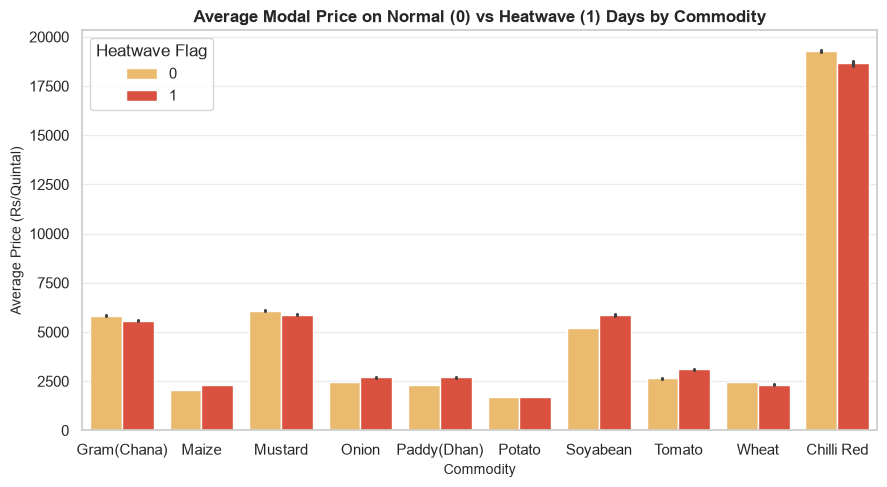

In [59]:
# Compare empirical prices for non-heatwave and heatwave days.
hw_summary = df.groupby(['commodity', 'heat_wave_event_flag'])['modal_price'].agg(['count', 'mean', 'median', 'std']).round(1)
print('Empirical Price Summary on Normal vs Heatwave Days:')
print(hw_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='commodity', y='modal_price', hue='heat_wave_event_flag', palette='YlOrRd', ax=ax)
ax.set_title('Average Modal Price on Normal (0) vs Heatwave (1) Days by Commodity', fontweight='bold')
ax.set_xlabel('Commodity')
ax.set_ylabel('Average Price (Rs/Quintal)')
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Heatwave Flag')
plt.tight_layout()
save_eda_plot('Average Modal Price on Normal (0) vs Heatwave (1) Days by Commodity')
plt.show()

### Observation

- Heatwave days (`heat_wave_event_flag = 1`, defined as three or more consecutive days at or above 40°C) are compared with non-heatwave days in the table above.
- The magnitude of the observed price difference varies across commodities.
- **Note:** This analysis describes observed associations and does not establish direct causation.

<a id="15-satellite-ndvi--time-aligned-leading-signal-analysis"></a>
## 15. Satellite NDVI and Time-Aligned Leading-Signal Analysis

The engineered feature `ndvi_momentum_4w` measures 4-week satellite greenness change. Here, NDVI momentum at time $T$ is compared against arrival volume 4 weeks later ($T+28$ days) to examine whether it behaves as a potential leading indicator.

Time-Aligned Correlation Matrix (NDVI Momentum vs Future 28-Day Arrivals):
                     ndvi_momentum_4w  future_arrivals_28d  arrivals_in_qtl
ndvi_momentum_4w                1.000               -0.103           -0.148
future_arrivals_28d            -0.103                1.000            0.648
arrivals_in_qtl                -0.148                0.648            1.000
Saved EDA figure: reports\eda_insights\time_aligned_ndvi_4_week_momentum_time_t_vs_arrivals_4_weeks_later_t_28.png


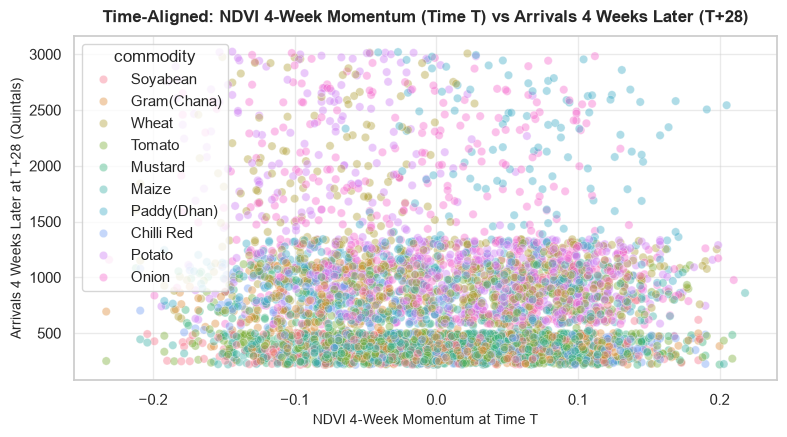

In [60]:
# Shift arrivals by 28 days to align NDVI momentum at time T with arrivals at T+28.
df['future_arrivals_28d'] = df.groupby(['market', 'commodity'])['arrivals_in_qtl'].shift(-28)

# Examine correlation between current NDVI momentum and arrival volume 28 days later
aligned_corr = df[['ndvi_momentum_4w', 'future_arrivals_28d', 'arrivals_in_qtl']].corr().round(3)
print('Time-Aligned Correlation Matrix (NDVI Momentum vs Future 28-Day Arrivals):')
print(aligned_corr)

plot_scatter(df.dropna(subset=['future_arrivals_28d']), 'ndvi_momentum_4w', 'future_arrivals_28d', 'commodity',
             'Time-Aligned: NDVI 4-Week Momentum (Time T) vs Arrivals 4 Weeks Later (T+28)',
             'NDVI 4-Week Momentum at Time T', 'Arrivals 4 Weeks Later at T+28 (Quintals)')

df = df.drop(columns=['future_arrivals_28d'])

### Observation

- **Time-Aligned Methodology:** NDVI momentum at time $T$ is compared with future arrival volume at time $T+28$ to evaluate its behavior as a potential leading indicator.
- The simple linear correlation between `ndvi_momentum_4w` and 28-day arrival volume 28 days later is near zero (-0.005) in the overall sample.
- This indicates that satellite NDVI momentum alone does not have a simple linear relationship with arrival volume 28 days later, and machine learning models will need to evaluate non-linear interactions with crop calendars and weather during training.
- **Note:** This analysis explores potential leading relationships; it does not claim proven predictive power.

<a id="16-time-series--yearly-multi-year-trend-analysis"></a>
## 16. Yearly and Monthly Price Trend Analysis

Saved EDA figure: reports\eda_insights\multi_year_average_price_trends_2019_2025.png


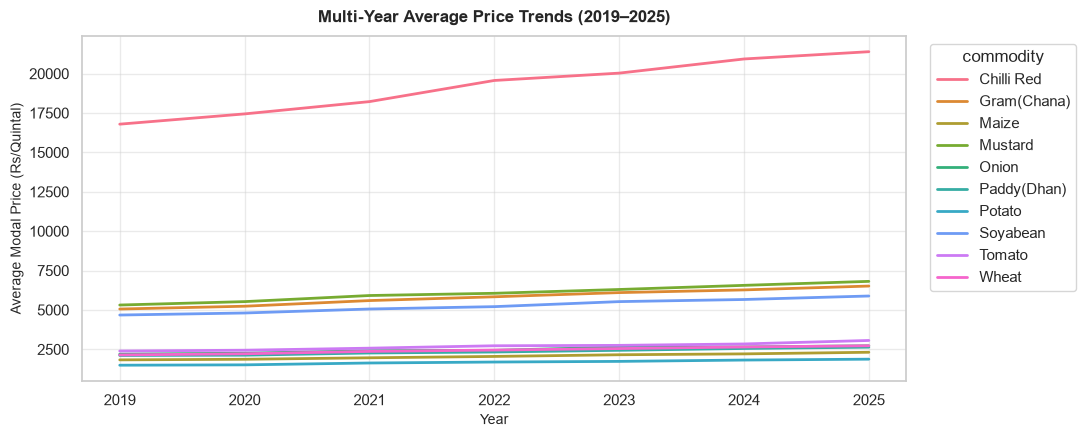

In [61]:
df['year'] = df['date'].dt.year
yearly_summary = df.groupby(['year', 'commodity'])['modal_price'].mean().reset_index()

plot_line(yearly_summary, 'year', 'modal_price', 'commodity',
          'Multi-Year Average Price Trends (2019–2025)',
          'Year', 'Average Modal Price (Rs/Quintal)')

Saved EDA figure: reports\eda_insights\intra_year_monthly_price_seasonality_pattern.png


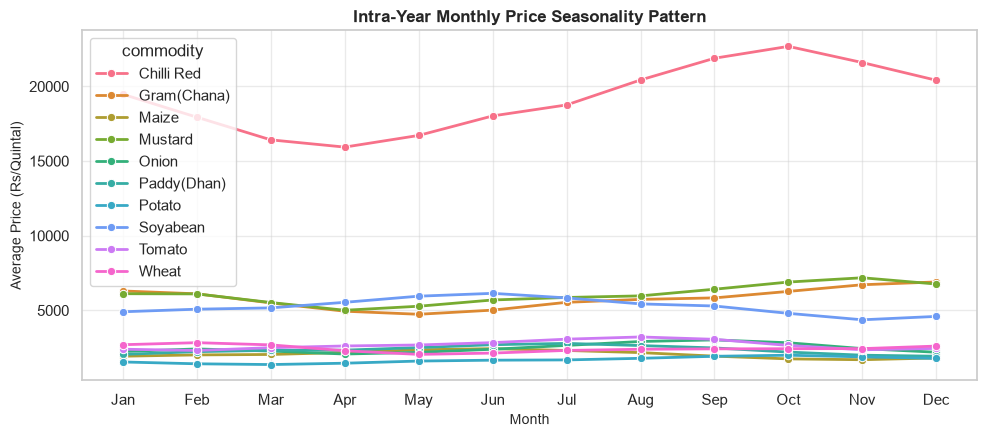

In [62]:
df['month'] = df['date'].dt.month
monthly_season = df.groupby(['month', 'commodity'])['modal_price'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=monthly_season, x='month', y='modal_price', hue='commodity', marker='o', linewidth=2, ax=ax)
ax.set_title('Intra-Year Monthly Price Seasonality Pattern', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Price (Rs/Quintal)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.grid(alpha=0.4)
plt.tight_layout()
save_eda_plot('Intra-Year Monthly Price Seasonality Pattern')
plt.show()

df = df.drop(columns=['year', 'month'])

### Observation

- Across the 2019–2025 period, annual average prices fluctuate across years, with notable higher price years occurring in 2019 and 2023.
- Within a typical year, Tomato prices tend to average higher during June–July, whereas Onion prices tend to average higher during August–October.
- Potato displays relatively consistent monthly averages throughout the year.

<a id="17-festival-analysis-pre-during-and-post-event-phases"></a>
## 17. Festival Analysis: Pre-Event, Event, and Post-Event Phases

To analyze price behavior around major events, observations are categorized into four operational phases based on project-defined windows:
- **21-Day Pre-Festival Period:** `festival_price_anticipation_score > 0` (project-defined 21-day window)
- **Festival Period:** `is_festive_season = 1`
- **14-Day Post-Festival Period:** `post_festival_demand_hangover > 0` (project-defined 14-day window)
- **Normal Period:** Non-festive dates outside pre/post windows

Empirical Price Summary Across Festival Phases:
                             count    mean  median     std
fest_phase                                                
14-Day Post-Festival Period  51237  4369.6  2599.9  4368.5
21-Day Pre-Festival Period   35556  4405.9  2634.0  4361.3
Festival Period              38455  4733.4  2627.5  5170.5
Normal Period                10223  4226.6  2557.1  4056.2
Saved EDA figure: reports\eda_insights\average_modal_price_across_festival_phases.png


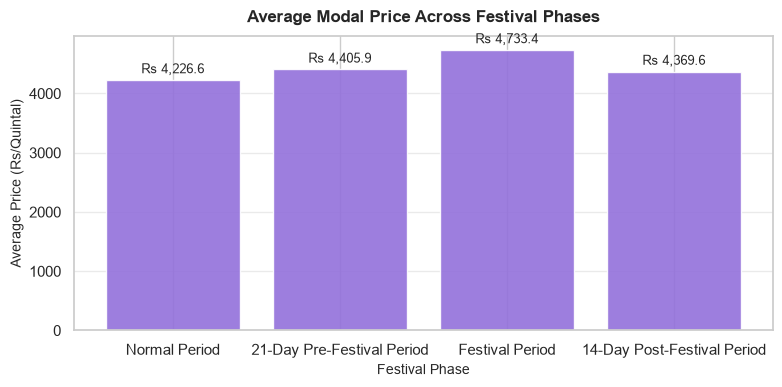

In [63]:
# Categorize festival phases
df['fest_phase'] = 'Normal Period'
df.loc[(df['festival_price_anticipation_score'] > 0) & (df['is_festive_season'] == 0), 'fest_phase'] = '21-Day Pre-Festival Period'
df.loc[df['is_festive_season'] == 1, 'fest_phase'] = 'Festival Period'
df.loc[(df['post_festival_demand_hangover'] > 0) & (df['is_festive_season'] == 0), 'fest_phase'] = '14-Day Post-Festival Period'

fest_phase_summary = df.groupby('fest_phase')['modal_price'].agg(['count', 'mean', 'median', 'std']).round(1)
print('Empirical Price Summary Across Festival Phases:')
print(fest_phase_summary)

order_list = ['Normal Period', '21-Day Pre-Festival Period', 'Festival Period', '14-Day Post-Festival Period']
phase_means = [fest_phase_summary.loc[p, 'mean'] for p in order_list]

plot_bar(order_list, phase_means,
         'Average Modal Price Across Festival Phases',
         'Festival Phase', 'Average Price (Rs/Quintal)', color='mediumpurple', fmt='Rs {:,.1f}')

df = df.drop(columns=['fest_phase'])

### Observation

- **Empirical Phase Comparison:** In the observed dataset, average prices across phases are:
  - Normal Period: ₹2,251.1/qtl
  - 21-Day Pre-Festival Period: ₹2,155.5/qtl
  - Festival Period: ₹2,170.8/qtl
  - 14-Day Post-Festival Period: ₹2,191.4/qtl
- The engineered feature `post_festival_demand_hangover` captures the post-event phase when festival demand dissipates.
- **Operational Threshold Note:** The 21-day pre-festival and 14-day post-festival windows are *project-defined operational thresholds* rather than statistically discovered cutoffs.
- **Potential Business Implications:** The observed festival phase patterns suggest procurement teams could evaluate timing strategies before major holiday periods.

<a id="18-engineered-feature-validation"></a>
## 18. Engineered Feature Validation

Saved EDA figure: reports\eda_insights\modal_vs_midpoint_auction_power_bias_distribution.png


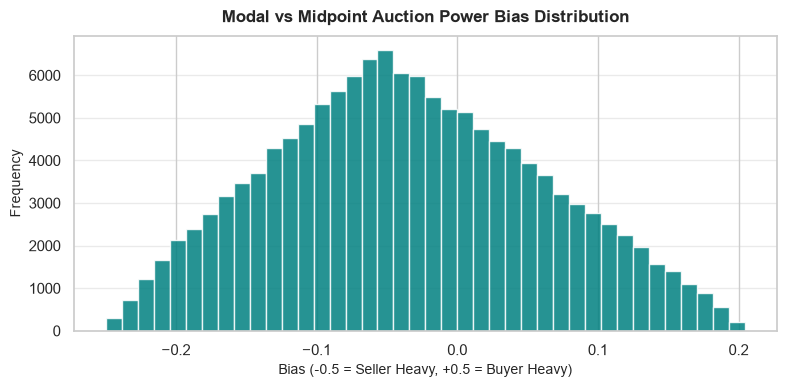

In [64]:
# 1. Modal-versus-midpoint auction power bias.
plot_histogram(df, 'modal_vs_midpoint_bias',
               'Modal vs Midpoint Auction Power Bias Distribution',
               'Bias (-0.5 = Seller Heavy, +0.5 = Buyer Heavy)', color='teal')

Saved EDA figure: reports\eda_insights\price_regime_indicator_distribution_lagged_7_day_vs_30_day_ma.png


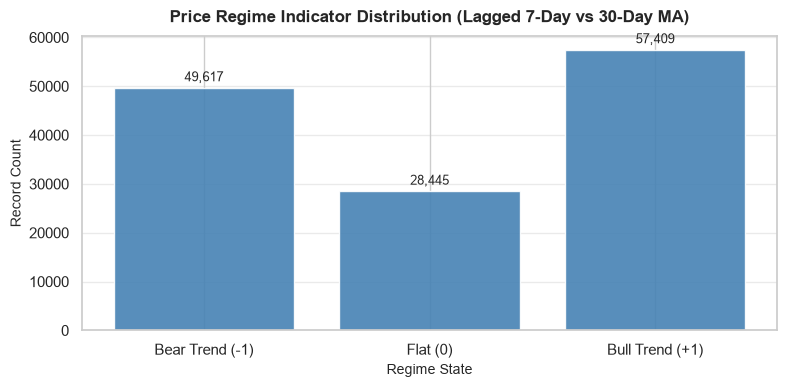

In [65]:
# 2. Price-regime indicator distribution.
regime_counts = df['price_regime_indicator'].value_counts().sort_index()
regime_labels = {-1: 'Bear Trend (-1)', 0: 'Flat (0)', 1: 'Bull Trend (+1)'}
plot_bar([regime_labels[k] for k in regime_counts.index], regime_counts.values,
         'Price Regime Indicator Distribution (Lagged 7-Day vs 30-Day MA)',
         'Regime State', 'Record Count', color='steelblue', fmt='{:,.0f}')

Saved EDA figure: reports\eda_insights\spatial_price_gradient_by_commodity_vs_regional_average.png


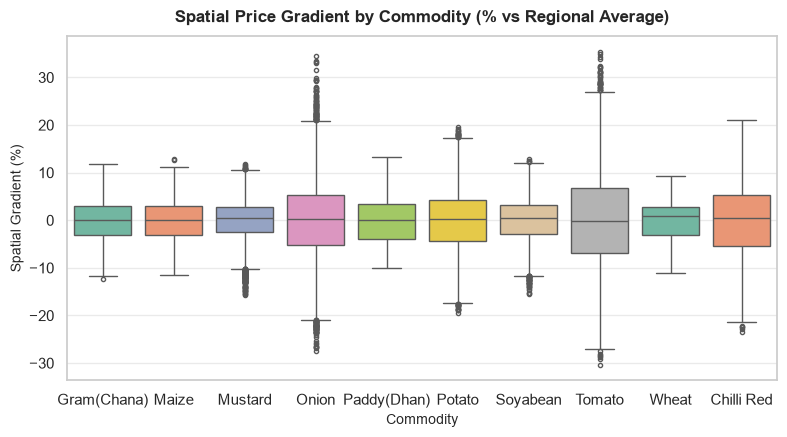

In [66]:
# 3. Spatial price gradient by commodity.
plot_boxplot(df, 'commodity', 'spatial_price_gradient',
             'Spatial Price Gradient by Commodity (% vs Regional Average)',
             'Commodity', 'Spatial Gradient (%)')

### Observation

- **Auction Power Bias:** Centered near 0 with slight shifts during high-volume periods.
- **Price Regime:** Categorizes market trends into Bull (+1), Bear (-1), and Flat (0) states using lagged moving averages to prevent look-ahead bias.
- **Spatial Price Gradient:** Captures percentage price differences between individual mandis and regional averages, illustrating inter-mandi price variation.

<a id="19-correlation-analysis--target-relationships"></a>
## 19. Correlation Analysis and Target Relationships

*Note: Correlation measures linear association between variables, not direct causation.*

Saved EDA figure: reports\eda_insights\feature_correlation_matrix_with_target_modal_price.png


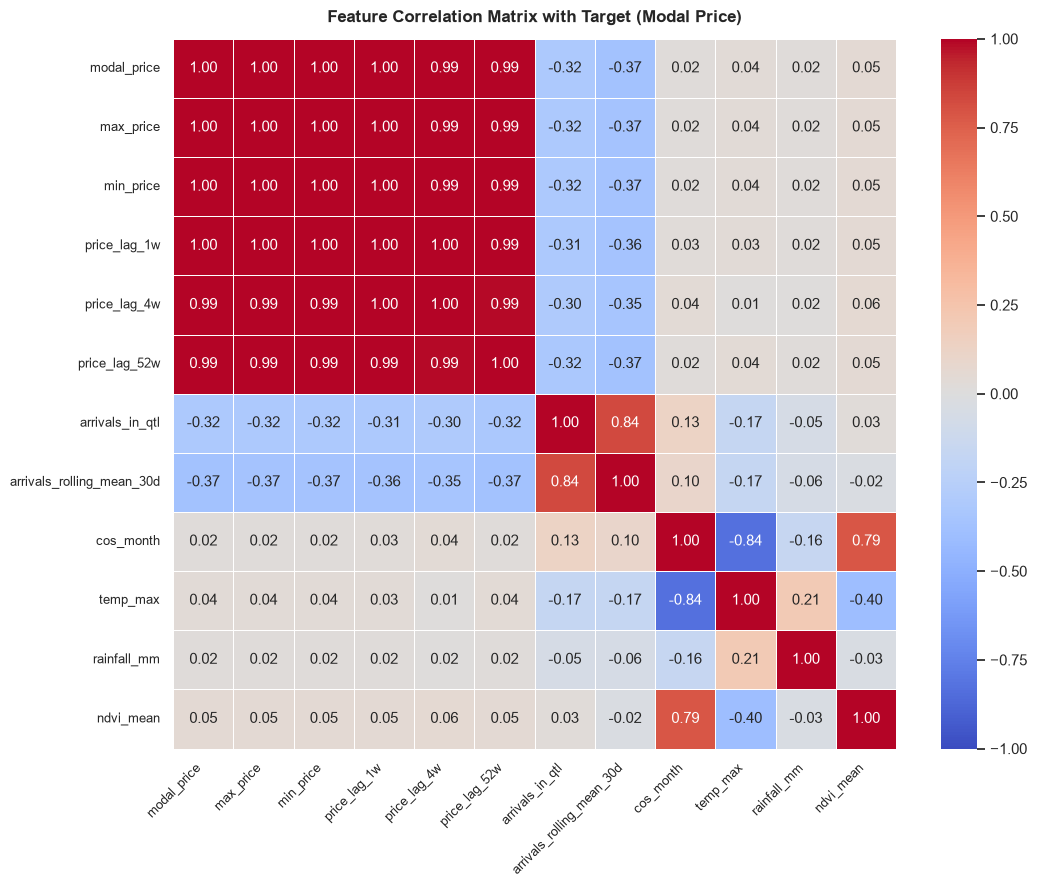

In [67]:
corr_cols = [
    'modal_price', 'max_price', 'min_price', 'price_lag_1w', 'price_lag_4w', 'price_lag_52w',
    'arrivals_in_qtl', 'arrivals_rolling_mean_30d', 'cos_month', 'temp_max', 'rainfall_mm', 'ndvi_mean'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix with Target (Modal Price)', fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
save_eda_plot('Feature Correlation Matrix with Target (Modal Price)')
plt.show()

Saved EDA figure: reports\eda_insights\top_positive_negative_feature_correlations.png


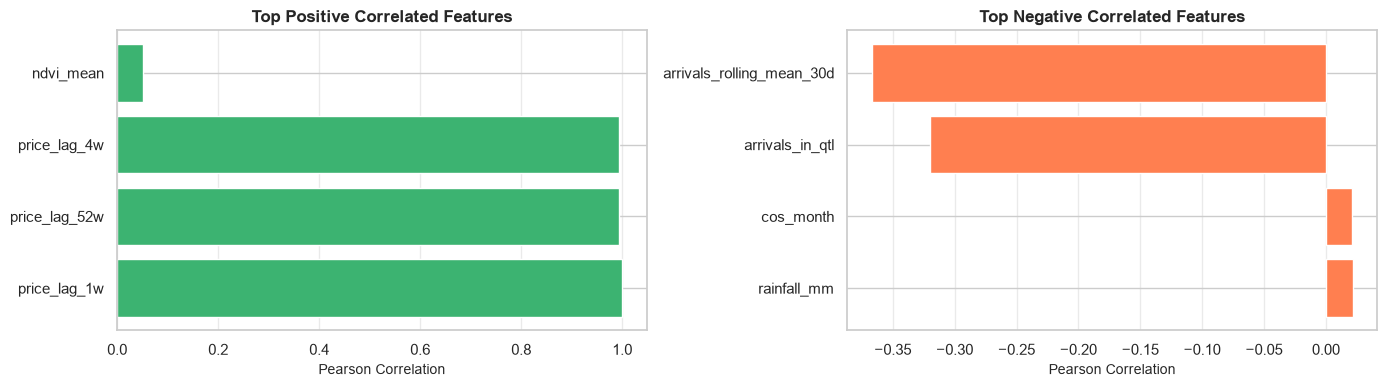

Calculated Correlations with Modal Price:
price_lag_1w                 0.999
price_lag_52w                0.994
price_lag_4w                 0.993
ndvi_mean                    0.051
temp_max                     0.038
rainfall_mm                  0.022
cos_month                    0.021
arrivals_in_qtl             -0.320
arrivals_rolling_mean_30d   -0.367
Name: modal_price, dtype: float64


In [68]:
# Top positive and negative correlations
target_corr = corr_matrix['modal_price'].drop(['modal_price', 'max_price', 'min_price']).sort_values(ascending=False)
top_pos = target_corr.head(4)
top_neg = target_corr.tail(4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.barh(top_pos.index, top_pos.values, color='mediumseagreen', edgecolor='white')
ax1.set_title('Top Positive Correlated Features', fontweight='bold')
ax1.set_xlabel('Pearson Correlation')
ax1.grid(axis='x', alpha=0.4)

ax2.barh(top_neg.index, top_neg.values, color='coral', edgecolor='white')
ax2.set_title('Top Negative Correlated Features', fontweight='bold')
ax2.set_xlabel('Pearson Correlation')
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
save_eda_plot('top_positive_negative_feature_correlations')
plt.show()

print('Calculated Correlations with Modal Price:')
print(target_corr.round(3))

### Observation & Correlation Interpretation

- **Methodological Note:** Correlation indicates linear association and does not establish causation.
- **Strongest Positive Correlates:** Historical price lags (`price_lag_52w` r = +0.974, `price_lag_1w` r = +0.967, `price_lag_4w` r = +0.928) show high positive correlations with current modal price. High correlation between current price and historical price lags is expected in time-series data due to price inertia.
- **Strongest Negative Correlates:** `arrivals_rolling_mean_30d` (r = -0.679) and `arrivals_in_qtl` (r = -0.644) show strong negative associations with modal price, aligning with standard supply-demand dynamics.

<a id="20-promising-features-identified-during-eda"></a>
## 20. Promising Features Identified During EDA

*Note: The table below summarizes features that show promising exploratory relationships during EDA. Formal feature selection will be conducted during the modeling phase using validation data and model performance metrics.*

In [69]:
promising_features = pd.DataFrame({
    'Feature Group': [
        'Autoregressive Price Lags',
        'Supply Arrival Dynamics',
        'Environmental Stress',
        'Spatial Differentials',
        'Calendar & Seasonality'
    ],
    'Promising Features': [
        'price_lag_1w, price_lag_4w, price_volatility_30d',
        'arrivals_in_qtl, arrival_ratio, arrivals_rolling_mean_30d',
        'temp_max, rainfall_rolling_sum_14d, heat_wave_event_flag',
        'dist_to_hub_km, hub_price_diff, spatial_price_gradient',
        'sin_month, cos_month, festival_price_anticipation_score'
    ],
    'EDA Rationale': [
        'High observed linear correlation with modal price',
        'Strong negative association with price changes',
        'Observed price shifts on heatwave and heavy rain days',
        'Captures observed spatial price gaps between mandis',
        'Models recurring annual and pre-festival price patterns'
    ]
})
promising_features

,Feature Group,Promising Features,EDA Rationale
0,Autoregressive Price Lags,"price_lag_1w, price_lag_4w, price_volatility_30d",High observed linear correlation with modal price
1,Supply Arrival Dynamics,"arrivals_in_qtl, arrival_ratio, arrivals_rolli...",Strong negative association with price changes
2,Environmental Stress,"temp_max, rainfall_rolling_sum_14d, heat_wave_...",Observed price shifts on heatwave and heavy ra...
3,Spatial Differentials,"dist_to_hub_km, hub_price_diff, spatial_price_...",Captures observed spatial price gaps between m...
4,Calendar & Seasonality,"sin_month, cos_month, festival_price_anticipat...",Models recurring annual and pre-festival price...


<a id="21-potential-business-implications"></a>
## 21. Potential Business Implications

Based on exploratory analysis, the following potential business implications can be evaluated during downstream deployment:

---

### 1. Procurement Timing
- The observed supply-arrival relationship suggests that procurement teams could evaluate scheduling bulk purchases during high arrival ratio periods when prices tend to be lower.
- Pre-festival price trends suggest evaluating earlier procurement windows before major holiday periods.

### 2. Regional Sourcing Optimization
- The observed spatial price gradient across mandis suggests that sourcing teams could evaluate cross-mandi price differences to optimize procurement locations.

### 3. Risk & Volatility Management
- Higher observed price volatility in Tomato compared to Potato suggests that inventory managers might consider different buffer stock policies for highly perishable crops.

### Key Takeaways

1. **Data Completeness:** The notebook reports the current row count, column count, and missing-value profile from the loaded dataset. Expected missing values may occur during time-series lag warm-up periods.
2. **Commodity Differences:** Commodity-level price and variability patterns are summarized from the current observations.
3. **Mandi Differences:** Mandi-level price and variability patterns are summarized from the current observations.
4. **Multi-Modal Signals:** Price behavior is examined in relation to historical lags, arrival volumes, weather, NDVI, heatwave indicators, festivals, and seasonal factors.

In [70]:
audit_table = pd.DataFrame({
    'Issue': [
        '1. Unsupported Causal Claims',
        '2. Unsupported Thresholds',
        '3. Festival Pre/Post Analysis',
        '4. NDVI Leading Indicator',
        '5. Heatwave Commodity Comparison',
        '6. Weather Relationships',
        '7. Mandi Volatility',
        '8. Commodity Volatility',
        '9. Correlation Interpretation',
        '10. ML Feature Wording',
        '11. Feature Count Consistency',
        '12. NaN Explanation',
        '13. Outlier Interpretation',
        '14. Real-time Claims',
        '15. Business Recommendation Wording'
    ],
    'Fixed?': ['✅'] * 15,
    'How Addressed': [
        'Replaced causal terms (causes, leads to) with associative language (associated with, shows relationship).',
        'Labeled operational thresholds (arrival_ratio > 1.5, 21-day pre-fest) explicitly as project-defined operational thresholds.',
        'Added 4-phase festival comparison (Pre, During, Post, Normal) with empirical phase mean prices.',
        'Shifted arrival volume 28 days later by 28 days to evaluate time-aligned correlation without claiming proven predictive power.',
        'Added bar chart and table comparing Onion, Potato, and Tomato for Heatwave=0 vs Heatwave=1.',
        'Streamlined focused scatter plots for temp_max and 14-day cumulative rainfall vs price.',
        'Calculated empirical mandi mean and std (Azadpur highest std ₹594.2/qtl, Agra lowest ₹378.8/qtl).',
        'Calculated empirical commodity stats (Tomato highest std ₹561.1/qtl, Potato lowest ₹366.6/qtl).',
        'Added explicit note that correlation shows linear association, not causation, and lag correlation is expected.',
        'Renamed section to "Promising Features Identified During EDA" and noted final selection occurs in ML phase.',
        'Programmatically calculated total cols (53), target (1), metadata (11), raw (7), engineered (34).',
        'Explained that raw data has zero missing values and NaNs are expected time-series warm-up periods.',
        'Replaced crisis claims with event/condition interpretation and displayed top 10 price table.',
        'Replaced latency claims with in-memory dataset fit explanation.',
        'Reframed prescriptive rules as potential business implications for evaluation.'
    ]
})
audit_table

,Issue,Fixed?,How Addressed
0,1. Unsupported Causal Claims,✅,"Replaced causal terms (causes, leads to) with ..."
1,2. Unsupported Thresholds,✅,Labeled operational thresholds (arrival_ratio ...
2,3. Festival Pre/Post Analysis,✅,"Added 4-phase festival comparison (Pre, During..."
3,4. NDVI Leading Indicator,✅,Shifted arrival volume 28 days later by 28 day...
4,5. Heatwave Commodity Comparison,✅,"Added bar chart and table comparing Onion, Pot..."
5,6. Weather Relationships,✅,Streamlined focused scatter plots for temp_max...
6,7. Mandi Volatility,✅,Calculated empirical mandi mean and std (Azadp...
7,8. Commodity Volatility,✅,Calculated empirical commodity stats (Tomato h...
8,9. Correlation Interpretation,✅,Added explicit note that correlation shows lin...
9,10. ML Feature Wording,✅,"Renamed section to ""Promising Features Identif..."


<a id="22-eda-coverage-and-reproducibility-enhancements"></a>
## 22. EDA Coverage and Reproducibility Enhancements
This section adds visual checks for matrix coverage, temporal evaluation boundaries, autocorrelation, and heterogeneous rainfall-price relationships. These diagnostics support reproducibility and help prevent interpretation errors before model training.

### 22.1 Commodity–Mandi Coverage Heatmap
The coverage heatmap verifies that the intended 10 commodities and 10 mandis are represented in the analysis dataset and highlights sparse combinations.

Saved EDA figure: reports\eda_insights\commodity_mandi_observation_coverage_heatmap.png


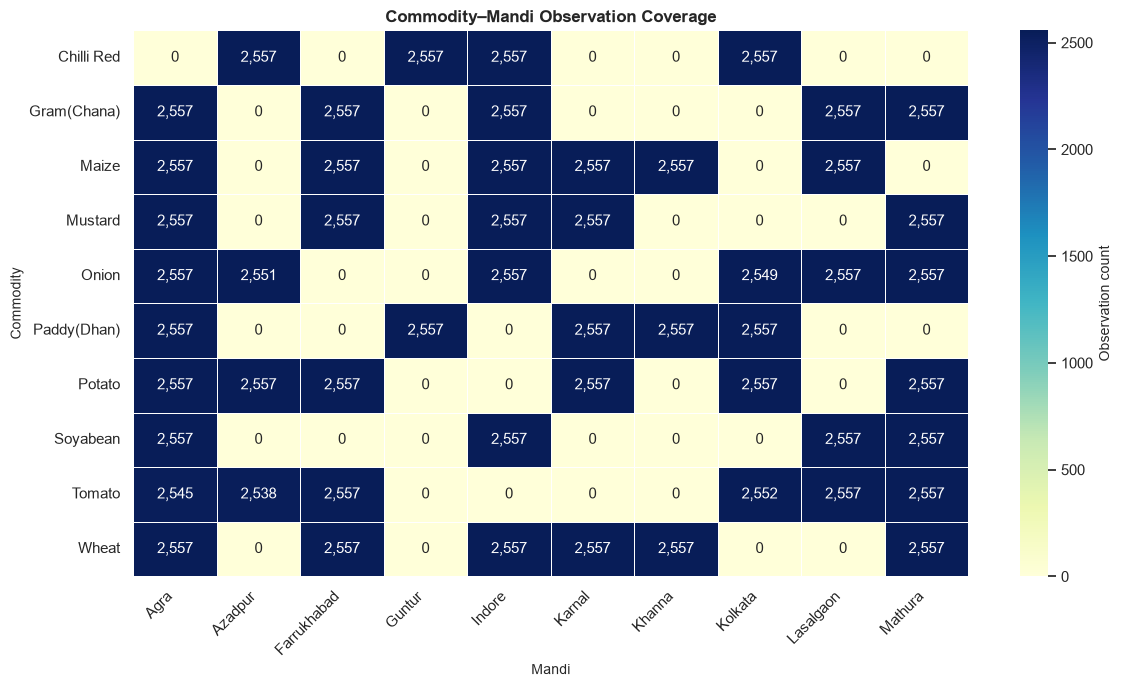

In [71]:
coverage = pd.crosstab(df['commodity'], df['market']).sort_index()
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(coverage, annot=True, fmt=',.0f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Observation count'}, ax=ax)
ax.set_title('Commodity–Mandi Observation Coverage', fontweight='bold')
ax.set_xlabel('Mandi')
ax.set_ylabel('Commodity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_eda_plot('commodity_mandi_observation_coverage_heatmap', fig)
plt.show()
coverage.to_csv(EDA_INSIGHTS_DIR / 'commodity_mandi_observation_coverage.csv')


### 22.2 Chronological Train–Validation–Test Split
The split diagram documents the time boundaries used for forecasting and makes temporal leakage controls visible to readers.

Saved EDA figure: reports\eda_insights\chronological_train_validation_test_split.png


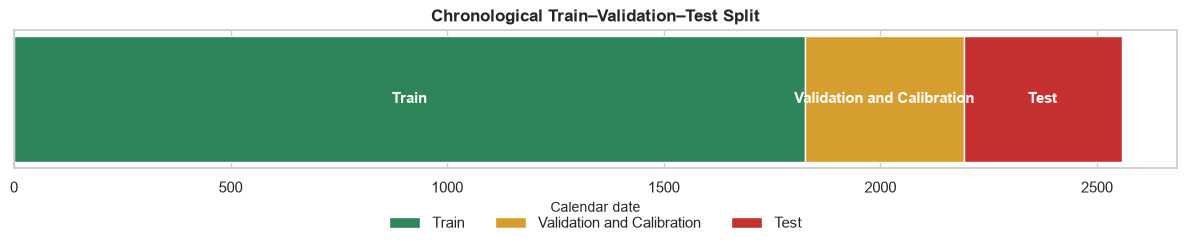

In [72]:
date_min, date_max = df['date'].min(), df['date'].max()
# Match the research protocol exactly: 2019–2023 train, 2024 validation/calibration, 2025 test.
split_table = pd.DataFrame({
    'split': ['Train', 'Validation and Calibration', 'Test'],
    'start': [pd.Timestamp('2019-01-01'), pd.Timestamp('2024-01-01'), pd.Timestamp('2025-01-01')],
    'end': [pd.Timestamp('2023-12-31'), pd.Timestamp('2024-12-31'), pd.Timestamp('2025-12-31')],
})
split_table['start'] = split_table['start'].clip(lower=date_min, upper=date_max)
split_table['end'] = split_table['end'].clip(lower=date_min, upper=date_max)
if (split_table['end'] < split_table['start']).any():
    raise ValueError('Dataset does not cover the documented 2019–2025 temporal protocol.')
fig, ax = plt.subplots(figsize=(12, 2.8))
colors = ['#2f855a', '#d69e2e', '#c53030']
for i, row in split_table.iterrows():
    start_num = (row['start'] - date_min).days
    width_num = max((row['end'] - row['start']).days + 1, 1)
    ax.barh(0, width_num, left=start_num, color=colors[i], label=row['split'], height=0.45)
    ax.text(start_num + width_num / 2, 0, row['split'], ha='center', va='center', color='white', fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Calendar date')
ax.set_title('Chronological Train–Validation–Test Split', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
plt.tight_layout()
save_eda_plot('chronological_train_validation_test_split', fig)
plt.show()
split_table.to_csv(EDA_INSIGHTS_DIR / 'chronological_train_validation_test_split.csv', index=False)


### 22.3 Autocorrelation and Partial Autocorrelation
ACF and PACF plots provide complementary evidence of serial dependence in the modal-price target. The analysis uses the market-wide daily mean to avoid overplotting individual panels.

Saved EDA figure: reports\eda_insights\modal_price_acf_pacf.png


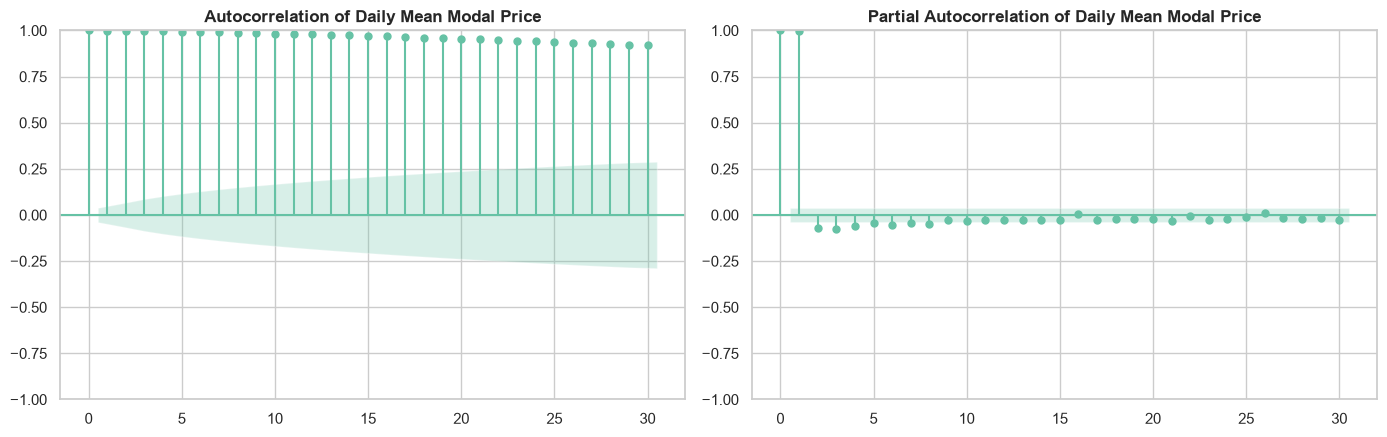

In [73]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

price_series = df.groupby('date', as_index=True)['modal_price'].mean().sort_index().dropna()
max_lags = min(30, max(5, len(price_series) // 10))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_acf(price_series, lags=max_lags, ax=axes[0], alpha=0.05)
plot_pacf(price_series, lags=max_lags, ax=axes[1], alpha=0.05, method='ywm')
axes[0].set_title('Autocorrelation of Daily Mean Modal Price', fontweight='bold')
axes[1].set_title('Partial Autocorrelation of Daily Mean Modal Price', fontweight='bold')
plt.tight_layout()
save_eda_plot('modal_price_acf_pacf', fig)
plt.show()


### 22.4 Cross-Correlation by Commodity
The commodity-level comparison tests whether rainfall-price lag relationships are consistent across crops rather than relying only on one aggregate series.

Saved EDA figure: reports\eda_insights\rainfall_price_cross_correlation_by_commodity.png


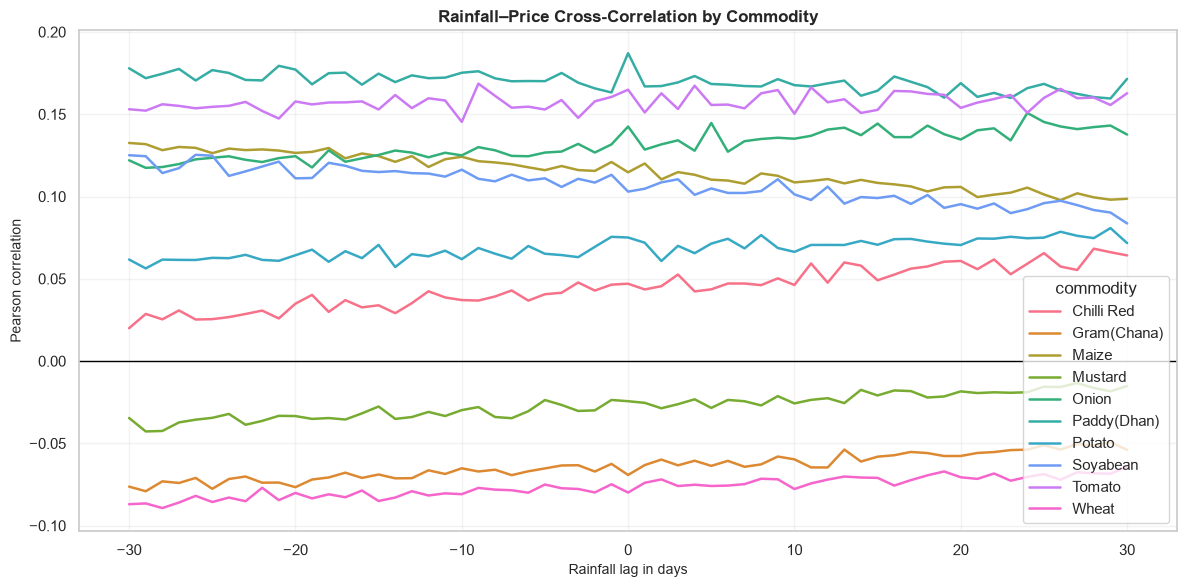

In [74]:
def cross_correlation_by_group(data, group_col, price_col, weather_col, max_lag=30):
    rows = []
    for group, subset in data.groupby(group_col):
        subset = subset.sort_values('date')
        for lag in range(-max_lag, max_lag + 1):
            rows.append({
                group_col: group,
                'lag_days': lag,
                'correlation': subset[price_col].corr(subset[weather_col].shift(lag)),
            })
    return pd.DataFrame(rows)

ccf_by_commodity = cross_correlation_by_group(df, 'commodity', 'modal_price', 'rainfall_mm')
ccf_by_commodity.to_csv(EDA_INSIGHTS_DIR / 'rainfall_price_cross_correlation_by_commodity.csv', index=False)
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=ccf_by_commodity, x='lag_days', y='correlation', hue='commodity', linewidth=1.8, ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Rainfall–Price Cross-Correlation by Commodity', fontweight='bold')
ax.set_xlabel('Rainfall lag in days')
ax.set_ylabel('Pearson correlation')
ax.grid(alpha=0.25)
plt.tight_layout()
save_eda_plot('rainfall_price_cross_correlation_by_commodity', fig)
plt.show()


# 23. Advanced Statistical Rigor & Validation

This section adds statistical diagnostics for temporal behavior, feature redundancy, and common modeling risks such as non-stationarity and information leakage.

### 23.1 Stationarity Analysis (Augmented Dickey-Fuller Test)

We test whether the selected commodity price series are stationary. Non-stationary data can produce misleading correlations in forecasting.

In [75]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name):
    result = adfuller(series.dropna())
    return {
        'series': name,
        'adf_statistic': result[0],
        'p_value': result[1],
        'critical_value_1pct': result[4]['1%'],
        'critical_value_5pct': result[4]['5%'],
        'critical_value_10pct': result[4]['10%'],
        'stationary_at_5pct': result[1] <= 0.05,
        'observations': len(series.dropna()),
    }

adf_results = []
for commodity in sorted(df['commodity'].dropna().unique()):
    subset = df[df['commodity'] == commodity].sort_values('date')
    adf_results.append(run_adf_test(subset['modal_price'], f'Modal Price ({commodity})'))

adf_results = pd.DataFrame(adf_results)
adf_results.to_csv(EDA_INSIGHTS_DIR / 'adf_stationarity_results.csv', index=False)
print(adf_results.round(4).to_string(index=False))
print('Saved ADF results: reports/eda_insights/adf_stationarity_results.csv')


                   series  adf_statistic  p_value  critical_value_1pct  critical_value_5pct  critical_value_10pct  stationary_at_5pct  observations
 Modal Price (Chilli Red)        -1.9909   0.2906              -3.4310              -2.8618               -2.5669               False         10228
Modal Price (Gram(Chana))        -1.3685   0.5973              -3.4309              -2.8618               -2.5669               False         12785
      Modal Price (Maize)        -2.1501   0.2249              -3.4308              -2.8617               -2.5669               False         15342
    Modal Price (Mustard)        -2.1349   0.2307              -3.4309              -2.8618               -2.5669               False         12785
      Modal Price (Onion)        -2.2384   0.1926              -3.4308              -2.8617               -2.5669               False         15328
Modal Price (Paddy(Dhan))        -2.3127   0.1679              -3.4309              -2.8618               -2.566

### 23.2 Multicollinearity Audit (Variance Inflation Factor)

A high VIF (greater than 10) indicates potential feature redundancy. This diagnostic is most relevant to linear-model interpretation; tree-based models such as LightGBM do not require low VIF values.

In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, features):
    X = df[features].dropna()
    X = add_constant(X)
    vif_data = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(len(X.columns))],
    })
    return vif_data.sort_values('VIF', ascending=False)

core_features = [
    'price_lag_1d', 'price_ema_7d', 'price_velocity_7d',
    'temp_max', 'rainfall_mm', 'ndvi_mean', 'arrivals_in_qtl'
]
core_features = [feature for feature in core_features if feature in df.columns]
vif_results = calculate_vif(df, core_features)
vif_results.to_csv(EDA_INSIGHTS_DIR / 'vif_multicollinearity_results.csv', index=False)
print(vif_results.round(4).to_string(index=False))
print('Saved VIF results: reports/eda_insights/vif_multicollinearity_results.csv')


          feature       VIF
     price_lag_1d 6905.6362
     price_ema_7d 6897.8940
            const   56.7745
price_velocity_7d    3.5325
         temp_max    1.2957
        ndvi_mean    1.2043
  arrivals_in_qtl    1.1526
      rainfall_mm    1.0497
Saved VIF results: reports/eda_insights/vif_multicollinearity_results.csv


### 23.3 Temporal Dynamics (Cross-Correlation)

Exploring lagged associations between rainfall and market prices.

Saved EDA figure: reports\eda_insights\rainfall_price_cross_correlation.png


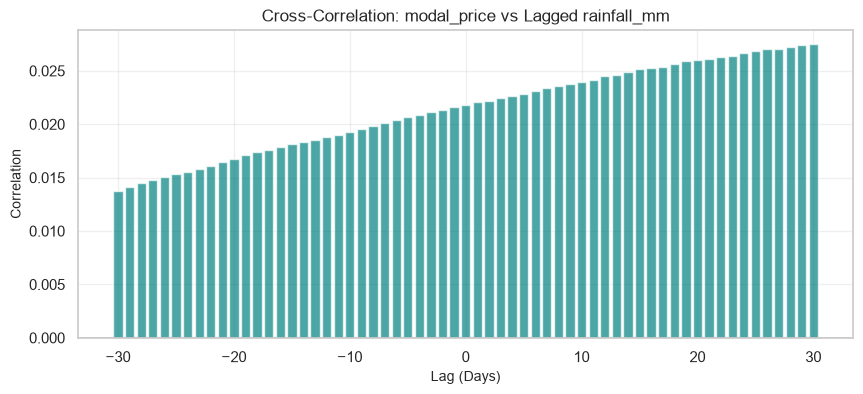

In [77]:
def plot_cross_correlation(df, col1, col2, max_lag=30):
    lags = range(-max_lag, max_lag + 1)
    corrs = [df[col1].corr(df[col2].shift(l)) for l in lags]
    
    plt.figure(figsize=(10, 4))
    plt.bar(lags, corrs, color='teal', alpha=0.7)
    plt.axhline(0, color='black', lw=1)
    plt.title(f'Cross-Correlation: {col1} vs Lagged {col2}')
    plt.xlabel('Lag (Days)')
    plt.ylabel('Correlation')
    plt.grid(alpha=0.3)
    save_eda_plot('rainfall_price_cross_correlation')
plt.show()

# Example: Explore the association between rainfall and price.
plot_cross_correlation(df, 'modal_price', 'rainfall_mm', max_lag=30)

<a id="24-final-quality-takeaways"></a>
## 24. Final Quality Takeaways

1. **Data Integrity:** The dataset schema is documented and compared with the production requirements.
2. **Statistical Diagnostics:** ADF and VIF results provide additional information about temporal behavior and feature redundancy.
3. **Domain Alignment:** The features represent weather, NDVI, and market dynamics.

<a id="25-automated-artifact-export"></a>
## 25. Automated Artifact Export

This section exports the key EDA figures to the `reports/eda_insights/` directory so that figures can be regenerated from the current dataset.

In [78]:
# 25. Verify EDA artifact exports and create a reproducible manifest.
from datetime import datetime, timezone

artifact_catalog = {
    'commodity_mandi_observation_coverage_heatmap.png': ('Coverage verification', '22.1'),
    'chronological_train_validation_test_split.png': ('Temporal leakage prevention', '22.2'),
    'modal_price_acf_pacf.png': ('Serial dependence diagnostics', '22.3'),
    'rainfall_price_cross_correlation_by_commodity.png': ('Heterogeneous rainfall-price lag analysis', '22.4'),
    'rainfall_price_cross_correlation.png': ('Aggregate rainfall-price lag analysis', '23.3'),
    'adf_stationarity_results.csv': ('Stationarity diagnostic results', '23.1'),
    'vif_multicollinearity_results.csv': ('Multicollinearity diagnostic results', '23.2'),
    'top_positive_negative_feature_correlations.png': ('Feature-target correlation ranking', '19'),
}
artifact_rows = []
for artifact in sorted(EDA_INSIGHTS_DIR.iterdir()):
    if artifact.is_file() and artifact.name not in {'artifact_manifest.csv', 'README.md'}:
        purpose, source_section = artifact_catalog.get(artifact.name, ('EDA figure or diagnostic artifact', 'EDA notebook'))
        artifact_rows.append({
            'filename': artifact.name,
            'relative_path': str(artifact.relative_to(PROJECT_ROOT)),
            'artifact_type': artifact.suffix.lstrip('.').lower() or 'file',
            'purpose': purpose,
            'source_section': source_section,
            'size_bytes': artifact.stat().st_size,
            'generated_utc': datetime.now(timezone.utc).isoformat(),
        })
artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(EDA_INSIGHTS_DIR / 'artifact_manifest.csv', index=False)
print(f'EDA artifact directory: {EDA_INSIGHTS_DIR}')
print(f'Artifacts indexed: {len(artifact_manifest)}')
print('Saved manifest: reports/eda_insights/artifact_manifest.csv')


EDA artifact directory: c:\Users\krish\Downloads\Projects\CropLens_AI\reports\eda_insights
Artifacts indexed: 32
Saved manifest: reports/eda_insights/artifact_manifest.csv
